# Анализ пользовательского поведения и проверка гипотез для сервиса аренды самокатов.
Цель проекта — изучить структуру клиентской базы, особенности использования сервиса и оценить влияние платной подписки на выручку компании.
В рамках анализа проведена предобработка данных, исследовательский анализ (EDA) и статистические тесты для проверки ключевых бизнес-гипотез.

# Описание данных

Таблица с пользователями `users_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `name` — имя пользователя.

- `age` — возраст.

- `city` — город.

- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`

- `subscription_type` — тип подписки.

- `minute_price` — стоимость одной минуты поездки по этой подписке.

- `start_ride_price` — стоимость начала поездки.

- `subscription_fee` — стоимость ежемесячного платежа.

### 1.1 Загрузка и первичный анализ данных

In [ ]:
# Импортируем библиотеку pandas
import pandas as pd

In [ ]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

In [ ]:
# Выводим первые 5 строк каждого датафрейма
display(df_users_go.head())

display(df_rides_go.head())

display(df_subscriptions_go.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [ ]:
# Подсчёт количества строк в каждом датафрейме
rows_users = len(df_users_go)
rows_rides = len(df_rides_go)
rows_subs = len(df_subscriptions_go)
print(rows_users, rows_rides,rows_subs)

1565 18068 2


**Пользователи (df_users_go)**

Всего 1565 пользователей.

Присутствуют имена, возраст, город и тип подписки (free или ultra).

**Поездки (df_rides_go)**

18 068 записей о поездках это значит, что каждый пользователь совершал несколько поездок.

Есть данные о расстоянии, длительности и дате поездки.

**Подписки (df_subscriptions_go)**

Всего 2 типа подписок (free и ultra), что совпадает с данными пользователей.

Есть цена за минуту, старт поездки и ежемесячная плата.

---
## 2. Знакомство с данными и их предварительная подготовка

### 2.1 Определение типов данных

In [ ]:
# Проверяем типы данных каждой колонки
print(df_rides_go.dtypes)

user_id       int64
distance    float64
duration    float64
date         object
dtype: object


Почти все типы данных корректные, date — пока object, нужно преобразовать в тип datetime

In [ ]:
# Преобразуем столбец 'date' в формат datetime
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

# Проверим результат
print(df_rides_go.dtypes)
print(df_rides_go.head())

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object
   user_id     distance   duration       date
0        1  4409.919140  25.599769 2021-01-01
1        1  2617.592153  15.816871 2021-01-18
2        1   754.159807   6.232113 2021-04-20
3        1  2694.783254  18.511000 2021-08-11
4        1  4028.687306  26.265803 2021-08-28


In [ ]:
# Создаём столбец с номером месяца
df_rides_go['month'] = df_rides_go['date'].dt.month

# Проверим результат
print(df_rides_go[['date', 'month']].head())

        date  month
0 2021-01-01      1
1 2021-01-18      1
2 2021-04-20      4
3 2021-08-11      8
4 2021-08-28      8


### 2.4 Поиск дублей и пропусков


In [ ]:
# Количество пропусков в df_users_go
num_missing = df_users_go.isnull().sum().sum()

# Количество дубликатов в df_users_go
num_duplicates = df_users_go.duplicated().sum()

# Вывод в формате "пропуски дубликаты"
print(num_missing, num_duplicates)

0 31


### 2.5 Заполнение пропусков и удаление дублей


In [ ]:
# Заполнение пропусков нулями
df_users_go = df_users_go.fillna(0)
df_rides_go = df_rides_go.fillna(0)
df_subscriptions_go = df_subscriptions_go.fillna(0)

# Удаление дубликатов
df_users_go = df_users_go.drop_duplicates()
df_rides_go = df_rides_go.drop_duplicates()
df_subscriptions_go = df_subscriptions_go.drop_duplicates()

# Проверим результаты
print("Пропуски после обработки df_users_go:\n", df_users_go.isnull().sum())
print("Дубликаты после обработки df_users_go:", df_users_go.duplicated().sum())

Пропуски после обработки df_users_go:
 user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64
Дубликаты после обработки df_users_go: 0


### 2.6 Подготовка данных о длительности поездки
В датафрейме поездок `df_rides_go` округлите время поездки `duration` до целого числа стандартным методом `round()`. Затем приведите эту колонку к целочисленному типу `int`. Этот шаг затем поможет вам правильно рассчитать прибыль, так как плата взимается только за целое число минут.

In [ ]:
# Округляем duration до целого числа и приводим к типу int
df_rides_go['duration'] = df_rides_go['duration'].round().astype(int)

# Проверим результат
print(df_rides_go[['duration']].head())
print(df_rides_go.dtypes)

   duration
0        26
1        16
2         6
3        19
4        26
user_id              int64
distance           float64
duration             int64
date        datetime64[ns]
month                int64
dtype: object


---
## 3. Исследовательский анализ данных (EDA)



In [ ]:
import matplotlib.pyplot as plt

### 3.2 Подсчет количества пользователей по городам.


In [ ]:
# Подсчёт количества пользователей по городам в виде Series
users_by_city_count = df_users_go['city'].value_counts()

# Вывод
print(users_by_city_count)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


### 3.3 Считаем количество пользователей с подпиской


In [ ]:
# Подсчёт количества пользователей для каждого типа подписки
subscription_type_count = df_users_go['subscription_type'].value_counts()
print(subscription_type_count)

free     835
ultra    699
Name: subscription_type, dtype: int64


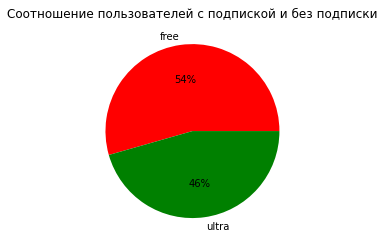

In [ ]:
# Визуализация с помощью круговой диаграммы
subscription_type_count.plot(
    kind='pie',  # тип диаграммы — круговая
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',  # отображение процентов без десятичных
    ylabel='',        # подпись оси Y убираем
    colors=['red', 'green']  # красный — free, зелёный — ultra
)

plt.show()

### 3.5 Анализ возрастных категорий пользователей самокатов

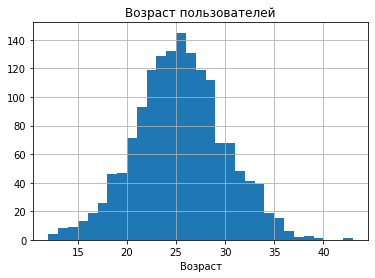

In [ ]:
# Определяем количество бинов как разницу между макс. и мин. возрастом
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

# Строим гистограмму
df_users_go['age'].hist(bins=n_bins)

# Настройка графика
plt.title('Возраст пользователей')
plt.xlabel('Возраст')

# Отображение графика
plt.show()

### 3.6 Определеяем долю несовершеннолетних пользователей

In [ ]:
# Логическая маска для пользователей младше 18 лет
under_18_count = df_users_go[df_users_go['age'] < 18].shape[0]

# Общее количество пользователей
total_users = df_users_go.shape[0]

# Доля несовершеннолетних в процентах (целое число)
users_under_18_ratio = int((under_18_count / total_users) * 100)

# Вывод результата
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


### 3.7 Анализируем характеристики длительности поездки


In [ ]:
# Среднее значение длительности поездки
duration_mean = int(round(df_rides_go['duration'].mean()))

# Стандартное отклонение
duration_std = int(round(df_rides_go['duration'].std()))

# 25-й и 75-й процентили
duration_pct25 = int(round(df_rides_go['duration'].quantile(0.25)))
duration_pct75 = int(round(df_rides_go['duration'].quantile(0.75)))

# Вывод
print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. '
      f'Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


---
## 4. Анализ таблиц пользователей и поездок и подписок

In [ ]:
# Объединяем df_users_go и df_rides_go по user_id
df = df_users_go.merge(df_rides_go, on='user_id', how='left')

# Проверим результат
print(df.head())
print(df.info())

   user_id  name  age    city subscription_type     distance  duration  \
0        1  Кира   22  Тюмень             ultra  4409.919140        26   
1        1  Кира   22  Тюмень             ultra  2617.592153        16   
2        1  Кира   22  Тюмень             ultra   754.159807         6   
3        1  Кира   22  Тюмень             ultra  2694.783254        19   
4        1  Кира   22  Тюмень             ultra  4028.687306        26   

        date  month  
0 2021-01-01      1  
1 2021-01-18      1  
2 2021-04-20      4  
3 2021-08-11      8  
4 2021-08-28      8  
<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  

### Задача 4.2 Присоединение информации о подписках
Присоедините к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`, используя метод `merge()` по общей колонке и тип объединения `left`.


In [ ]:
# Объединяем датафрейм df с информацией о подписках
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

# Проверим результат
print(df.head())
print(df.info())

   user_id  name  age    city subscription_type     distance  duration  \
0        1  Кира   22  Тюмень             ultra  4409.919140        26   
1        1  Кира   22  Тюмень             ultra  2617.592153        16   
2        1  Кира   22  Тюмень             ultra   754.159807         6   
3        1  Кира   22  Тюмень             ultra  2694.783254        19   
4        1  Кира   22  Тюмень             ultra  4028.687306        26   

        date  month  minute_price  start_ride_price  subscription_fee  
0 2021-01-01      1             6                 0               199  
1 2021-01-18      1             6                 0               199  
2 2021-04-20      4             6                 0               199  
3 2021-08-11      8             6                 0               199  
4 2021-08-28      8             6                 0               199  
<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column   

### Задача 4.3. Размеры объединённого датафрейма
Для финальной проверки выведите на экран первые пять строк датафрейма, а также количество строк и столбцов полученного датафрейма `df`. Этот этап позволит убедиться, что никакие записи не потерялись при объединении.

In [ ]:
# Вывод первых 5 строк датафрейма
display(df.head())

# Подсчёт количества строк и столбцов
n_rows, n_cols = df.shape

# Вывод результата
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### Задача 4.4 Отдельные датафреймы для пользователей с подпиской и без
Создайте два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`. В следующих заданиях два этих датафрейма пригодятся при изучении поведения пользователей с подпиской и без, а также при проверке продуктовых гипотез.

In [ ]:
# Датафрейм с пользователями без подписки (free)
df_free = df[df['subscription_type'] == 'free']

# Датафрейм с пользователями с подпиской (ultra)
df_ultra = df[df['subscription_type'] == 'ultra']

# Проверим результат
print("Первые строки df_free:")
display(df_free.head())

print("Первые строки df_ultra:")
display(df_ultra.head())

# Количество строк в каждом датафрейме
print(f"Количество поездок пользователей без подписки: {df_free.shape[0]}")
print(f"Количество поездок пользователей с подпиской: {df_ultra.shape[0]}")

Первые строки df_free:


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,15,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,10,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17,2021-02-14,2,8,50,0


Первые строки df_ultra:


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


Количество поездок пользователей без подписки: 11568
Количество поездок пользователей с подпиской: 6500


### 4.5 Вихуализация длительности поездок для обоих групп


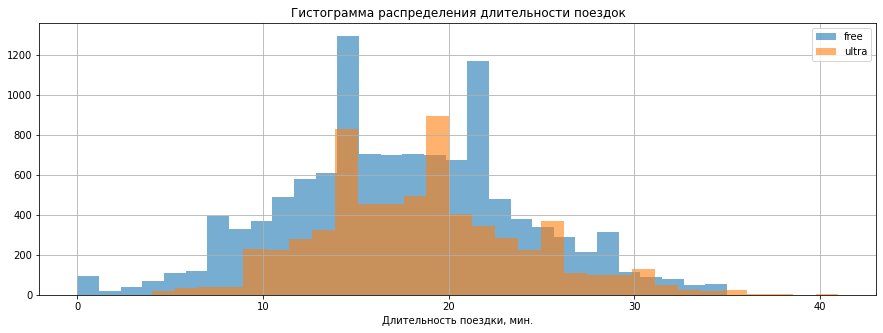

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [ ]:
# Построение гистограммы
plt.figure(figsize=(15, 5))

# Гистограмма для пользователей без подписки
df_free['duration'].hist(bins=30, alpha=0.6, label='free')

# Гистограмма для пользователей с подпиской
df_ultra['duration'].hist(bins=30, alpha=0.6, label='ultra')

# Настройка графика
plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()

# Отображение графика
plt.show()

# Расчет средней длительности поездки
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())

# Вывод результата
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, '
      f'а для пользователей с подпиской {mean_duration_ultra} мин')

---
## 5. Подсчёт выручки

### 5.1 Группировка необходимых данных


In [ ]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

### 5.2 Подсчёт агрегированных метрик
В новыом датафрейме `df_agg`, где:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

<details>
<summary>Открыть подсказку</summary>
В этом задании удобнее всего сделать агрегацию с использованием кортежей.
</details>

In [ ]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)
display(df_agg,5)

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199
1,1,Кира,4,754.159807,6,1,ultra,6,0,199
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...,...
11326,1534,Альберт,6,3409.468534,24,2,free,8,50,0
11327,1534,Альберт,8,7622.453034,47,2,free,8,50,0
11328,1534,Альберт,9,4928.173852,23,1,free,8,50,0
11329,1534,Альберт,11,13350.015305,76,4,free,8,50,0


5

### 5.3 Подсчет выручки
По формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

In [ ]:
def calculate_monthly_revenue(row):
    return (
        row['start_ride_price'] * row['rides_count']
        + row['minute_price'] * row['total_duration']
        + row['subscription_fee']
    )

### Задача 5.4 Создание столбца с месячной выручкой на пользователя
Создайте новый столбец с месячной выручкой на пользователя `monthly_revenue`. Для этого примените функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

In [ ]:
# Применяем функцию для расчёта месячной выручки к каждой строке
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

# Проверяем результат
display(df_agg.head())

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199,451
1,1,Кира,4,754.159807,6,1,ultra,6,0,199,235
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199,469
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199,391
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199,517


### Задача 5.5 Поиск пользователя с максимальной выручкой
Исследуйте полученные значения выручки. Найдите пользователя с максимальной суммарной выручкой за весь период наблюдения и для него выведите на экран `user_id`, имя, месяц, количество поездок и выручку за каждый из месяцев.

<details>
<summary>Открыть подсказку</summary>
Для найденного пользователя выведите колонки <code>user_id</code>, <code>name</code>, <code>month</code>, <code>rides_count</code>, <code>monthly_revenue</code>.
</details>

In [ ]:
# Считаем суммарную выручку каждого пользователя
total_revenue_by_user = df_agg.groupby(['user_id', 'name'], as_index=False)['monthly_revenue'].sum()

# Сортируем по суммарной выручке по убыванию
total_revenue_by_user = total_revenue_by_user.sort_values(by='monthly_revenue', ascending=False)

# Берём пользователя с максимальной суммарной выручкой
max_user_id = total_revenue_by_user.iloc[0]['user_id']

# Фильтруем строки по найденному пользователю
df_max_user = df_agg[df_agg['user_id'] == max_user_id]

# Выводим нужные колонки
display(df_max_user[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


---
## 6. Проверка гипотез

In [ ]:
import scipy.stats as st

In [ ]:
# Функция для интерпретации результатов статистического теста
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

# Проверка функции
print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.2 ПРоеряем гипотезу о том, что длительность для пользователей с подпиской вышем чем пользователей без

In [ ]:
# Длительность поездок для каждой группы
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

# Односторонний t-тест: проверяем гипотезу H1: Ultra > Free
t_stat, p_value = st.ttest_ind(ultra_duration, free_duration, alternative='greater')

# Интерпретация результата
print_stattest_results(p_value)

# Средняя длительность поездки для каждой группы
ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

# Вывод средних значений
print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


### 6.3 Проверяем гипотезу, что длительность поездок пользователей с подпиской больше 3130 м

In [ ]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, popmean=null_hypothesis, alternative='greater')
p_value = results[1]
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.5 Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

In [ ]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

# Односторонний t-тест: проверяем, что средняя выручка ultra > free
t_stat, p_value = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')

# Интерпретация результата
print_stattest_results(p_value)

# Средняя выручка для каждой группы
mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

# Вывод
print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## 7. Оценка доли поездок дольше 30 минут

### 7.1 Расчёт выборочного среднего и стандартного отклонения

In [ ]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


### 7.2 Вычисление значения функции распределения в точке 30 через CDF для того чтобы узнать вертяность поездки более 30 минут

In [ ]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему
from scipy.stats import norm
duration_norm_dist  = st.norm(loc=mu, scale=sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


### 7.3 Вычисляем процент пользователей, который совершает поездки в интервале от 20 до 30 минут (CDF)

In [ ]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


### 7.4 Определение критической дистанции поездок (PPF), которое превышается только в 10% поездок (90-й процентиль).


In [ ]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(loc=mu, scale=sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.



## Основные выводы

- В сервисе зарегистрировано 1565 пользователей и 18 068 поездок. Большинство пользователей используют сервис без подписки (free), однако доля подписчиков (ultra) также значительна.
- Основная аудитория сервиса — взрослые пользователи, доля несовершеннолетних составляет около 5%.
- Средняя длительность поездки составляет около 18 минут, при этом большинство поездок длится от 14 до 22 минут.
- Пользователи с подпиской совершают немного более длительные поездки (≈18.55 мин), чем пользователи без подписки (≈17.39 мин). Статистический тест показал значимое различие.
- Проверка гипотезы о дистанции поездок пользователей с подпиской показала, что нельзя утверждать, что средняя дистанция превышает 3130 м.
- Расчёт выручки показал, что доход формируется из стоимости старта поездки, оплаты за минуты использования и ежемесячной подписки.